# Task 3 — measured frozen GNN–BERT fusion

Review the completed five-head, three-seed comparison on 3,964 real MusicCaps
clips and 30 independent AudioSet labels. Default execution reads saved results;
it does not retrain or tune against test data. See `report/task3_results.md` for
interpretation and `docs/task3/README.md` for complete reproduction commands.

In [1]:
from pathlib import Path
import sys, json, re
import pandas as pd
from IPython.display import Image, display, Markdown
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RUN = ROOT / 'results/task3/available_run1'
assert (RUN / 'experiment.json').exists(), 'Run the real-data suite described in docs/task3/README.md first.'
experiment = json.loads((RUN / 'experiment.json').read_text(encoding='utf-8'))
selection = json.loads((RUN / 'selection.json').read_text(encoding='utf-8'))
verification = json.loads((RUN / 'verification.json').read_text(encoding='utf-8'))
print('Real data:', not experiment['synthetic'])
print('Seeds:', selection['seeds'])
print('Final evaluation complete:', experiment['evaluated_test'])
display(pd.DataFrame([{k: v for k, v in verification.items() if k not in {'checks', 'feature_sha256', 'selection_sha256'}}]))

Real data: True
Seeds: [42, 43, 44]
Final evaluation complete: True


,valid,runs_checked,evaluated_test,validation_only_selection,suite_declaration_verified,comparison_tables_verified
0,True,15,True,True,True,True


## Controlled comparison

Every head uses identical paired samples, labels and frozen encoder outputs.
DistilBERT was previously fine-tuned on 3,864 original training captions;
GraphSAGE on the 2,775 available-audio training clips. Held-out video IDs remain
disjoint from both training partitions. Only fusion-head initialization and batch
order change across seeds 42, 43 and 44.

Architecture selection uses mean validation Macro-F1. All test scores below
come from predeclared frozen controls with validation-selected thresholds.
Standard deviations describe head-seed variability, not confidence intervals.

,mode,validation_macro_f1_mean,test_macro_f1_mean,test_macro_f1_std,test_micro_f1_mean,test_map_mean
0,bert,0.462082,0.385024,0.005785,0.656417,0.389178
1,gnn,0.296704,0.253901,0.011909,0.563246,0.267959
2,concat,0.422831,0.383903,0.012450,0.656033,0.399412
3,gated,0.435323,0.370521,0.001317,0.646593,0.399460
4,cross_attention,0.423245,0.366547,0.010172,0.645307,0.386077


,mode,seed,best_epoch,threshold,validation_macro_f1,test_macro_f1,test_micro_f1,test_map
0,bert,42,8,0.15,0.460287,0.385931,0.664170,0.387990
1,gnn,42,6,0.10,0.297099,0.246008,0.548251,0.263962
2,concat,42,8,0.15,0.430881,0.387648,0.653025,0.395071
3,gated,42,4,0.15,0.429902,0.371973,0.634584,0.401218
4,cross_attention,42,10,0.15,0.417238,0.376878,0.638298,0.391654
5,bert,43,7,0.15,0.459242,0.378839,0.644418,0.384064
6,gnn,43,7,0.25,0.291545,0.248096,0.603424,0.271105
7,concat,43,4,0.15,0.419842,0.394050,0.655352,0.401654
8,gated,43,6,0.15,0.439045,0.369403,0.641986,0.409466
9,cross_attention,43,6,0.15,0.428855,0.366219,0.649385,0.383406


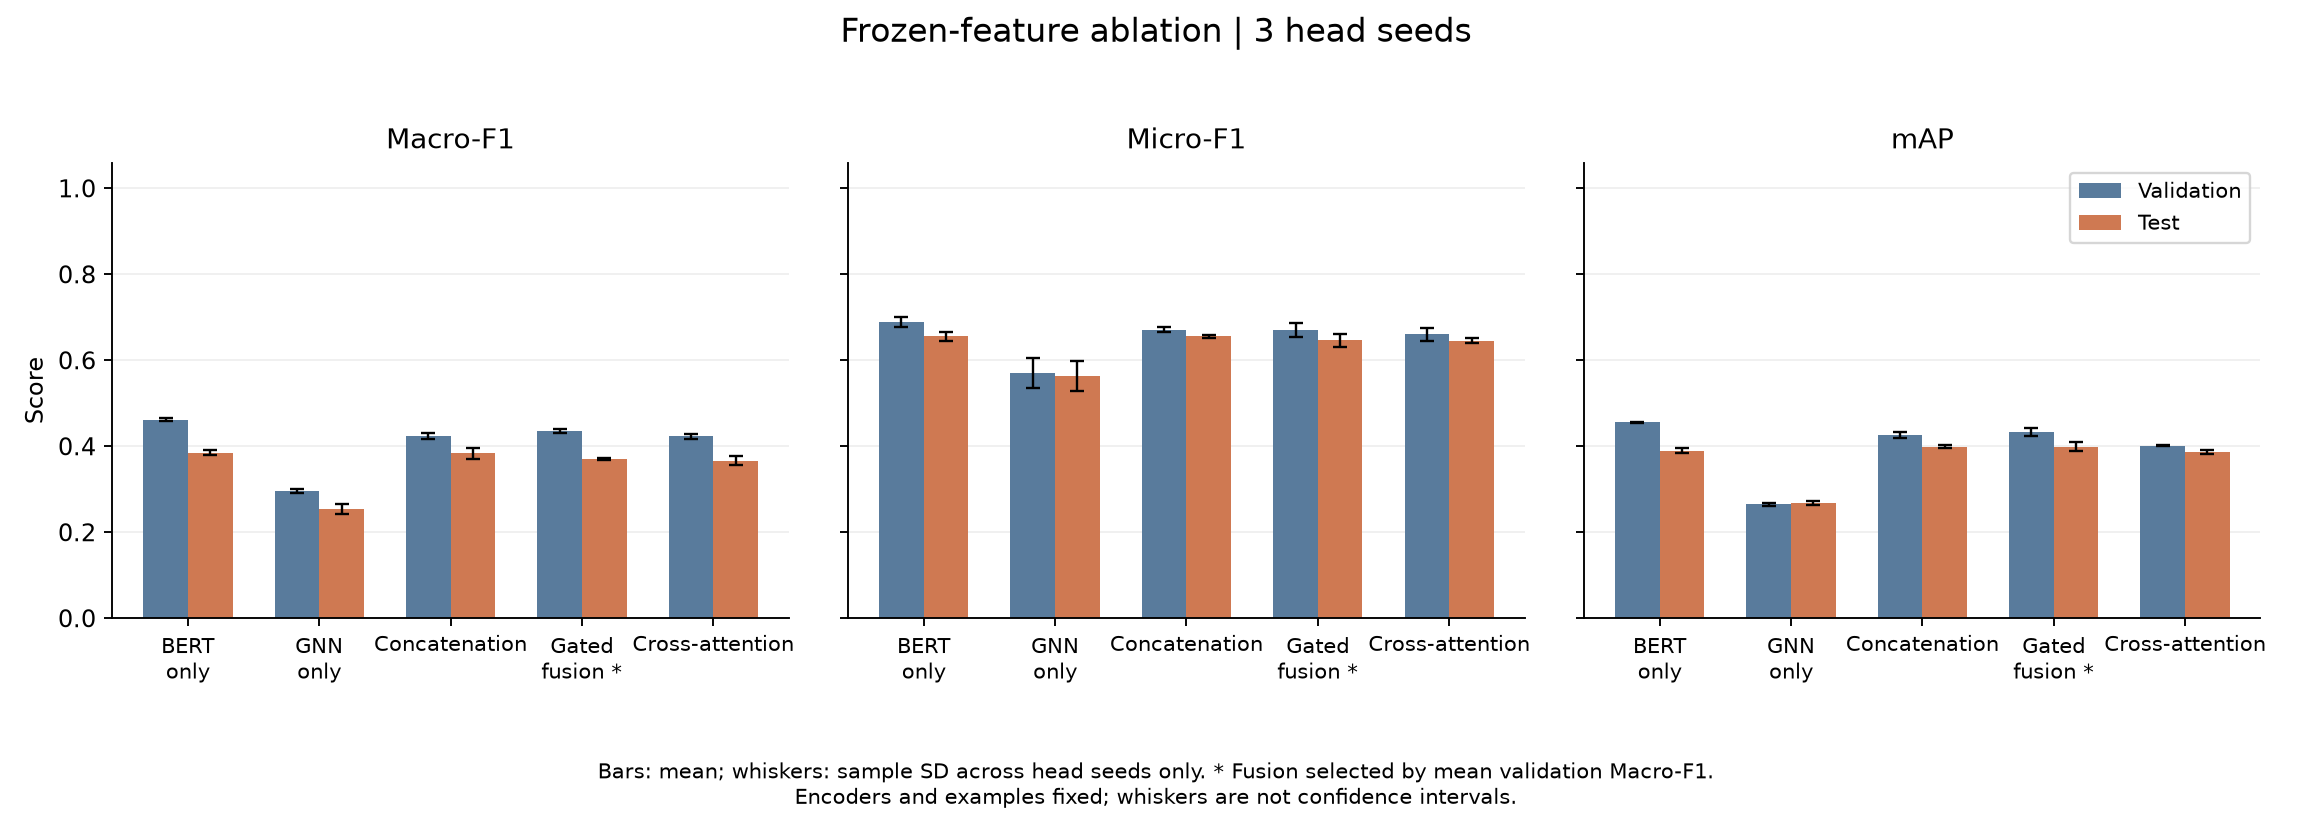

**Frozen validation selection**

{
  "criterion": "Mean validation Macro-F1; declaration order breaks ties",
  "selected_on": "validation",
  "selected_mode": "bert",
  "selected_fusion": "gated",
  "validation_means": {
    "bert": 0.46208150412569343,
    "gnn": 0.29670425773584913,
    "concat": 0.42283068213952263,
    "gated": 0.43532278659362617,
    "cross_attention": 0.42324541351255895
  },
  "seeds": [
    42,
    43,
    44
  ],
  "feature_sha256": "77c667b7312a6579ef17f0a29da5170781829a1a7849154b024794fa9d6a7513",
  "suite_config_sha256": "8ef07254d435979fbd74bc7741875e9e3f97f72f464c2bb934273fc0105d820c"
}


In [2]:
comparison = pd.read_csv(RUN / 'comparison.csv')
aggregate = pd.read_csv(RUN / 'comparison_aggregate.csv')
display(aggregate[['mode', 'validation_macro_f1_mean', 'test_macro_f1_mean', 'test_macro_f1_std', 'test_micro_f1_mean', 'test_map_mean']])
display(comparison[['mode', 'seed', 'best_epoch', 'threshold', 'validation_macro_f1', 'test_macro_f1', 'test_micro_f1', 'test_map']])
display(Image(filename=str(RUN / 'analysis/ablation.png')))
display(Markdown('**Frozen validation selection**'))
print(json.dumps({k: v for k, v in selection.items() if k not in {'runs'}}, indent=2))

## Measured learning curves and embeddings

Curves come from saved epoch logs. t-SNE shows the validation-selected fusion and
each seed's validation winner; axes are descriptive and do not measure class
separation quality or semantic understanding.

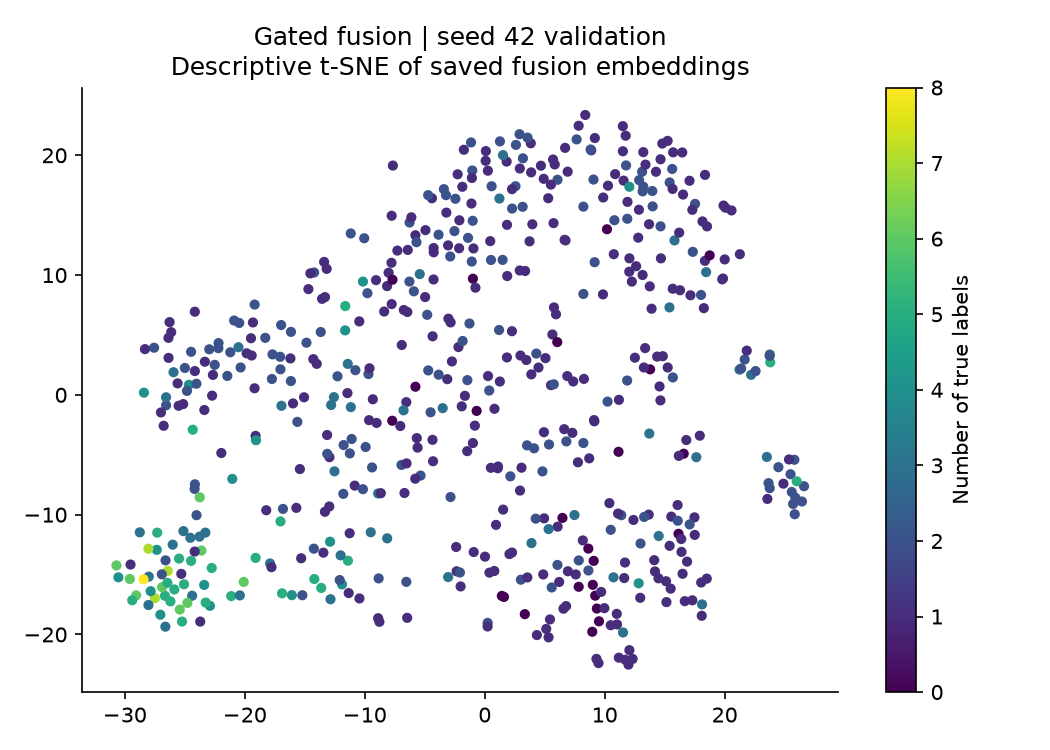

### Seed 42

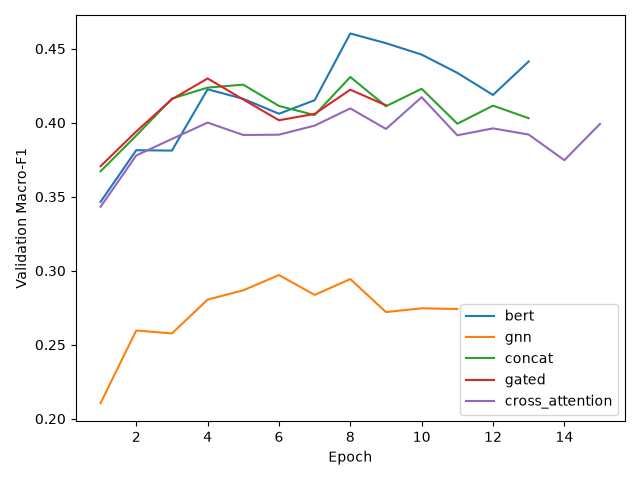

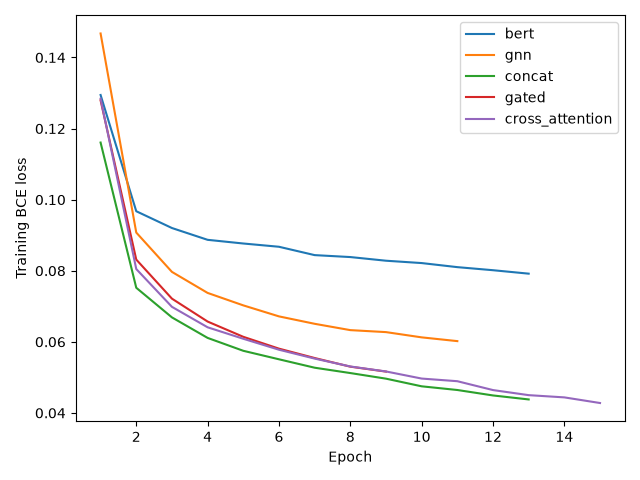

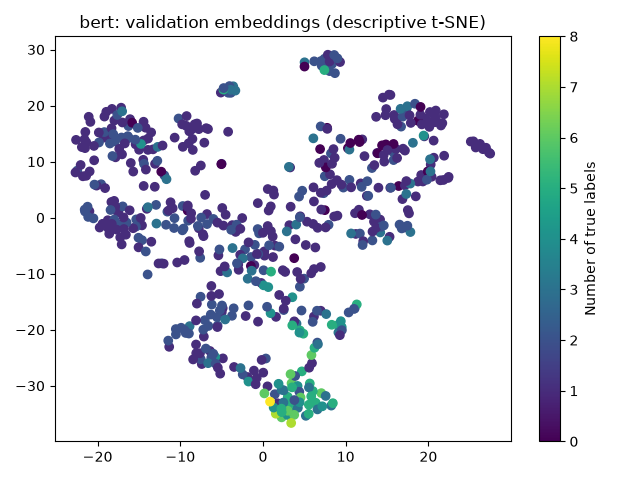

### Seed 43

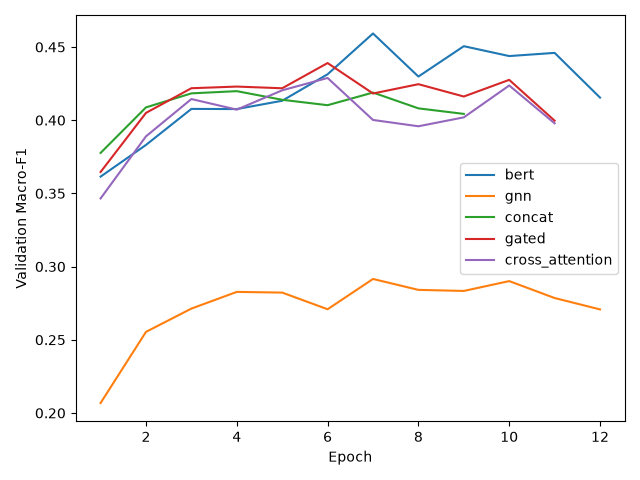

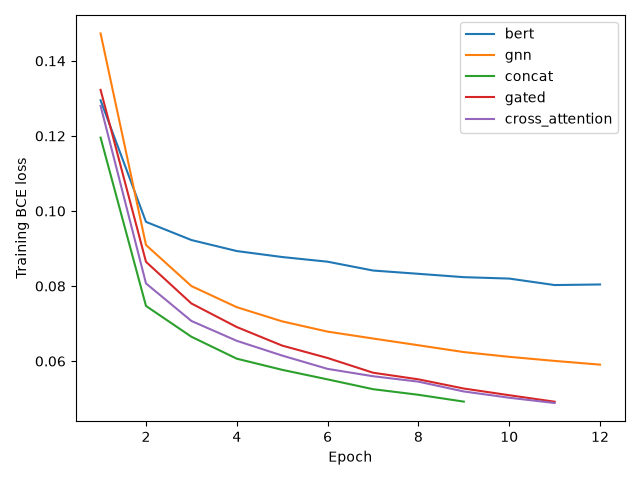

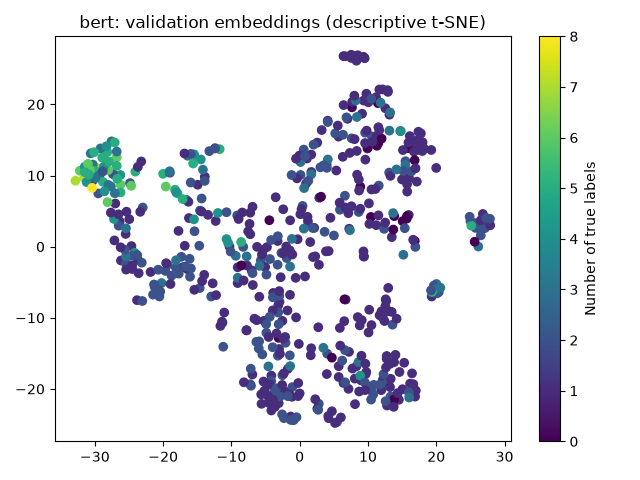

### Seed 44

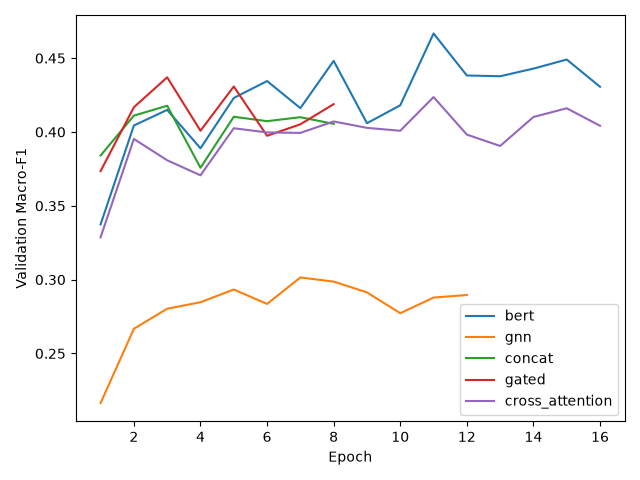

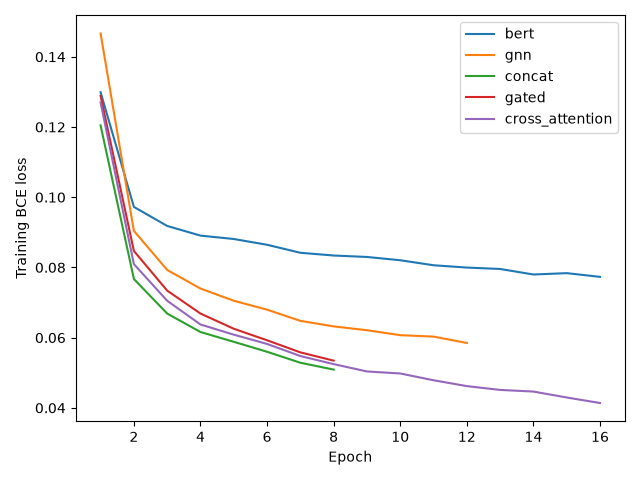

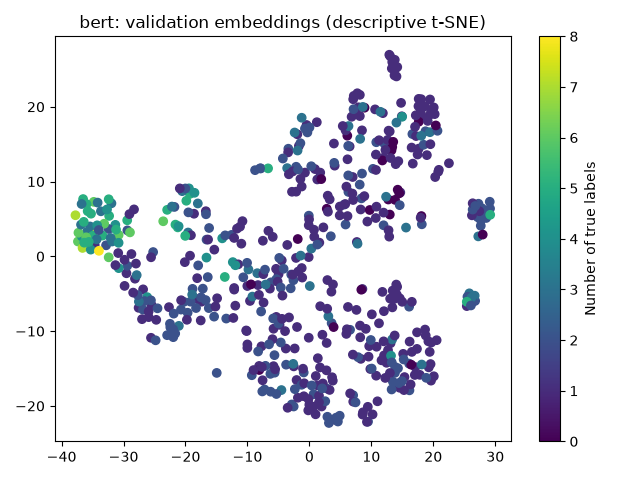

In [3]:
display(Image(filename=str(RUN / 'analysis/fusion_embeddings.png')))
for seed in selection['seeds']:
    display(Markdown(f'### Seed {seed}'))
    display(Image(filename=str(RUN / f'seed{seed}/validation_curves.png')))
    display(Image(filename=str(RUN / f'seed{seed}/training_curves.png')))
    display(Image(filename=str(RUN / f'seed{seed}/embeddings.png')))

## Three evidence-grounded cases

The first three validation IDs are fixed in cache order. These are diagnostics
of the seed-42 cross-attention head, irrespective of the winning architecture.
Token and graph-node vector interventions measure model sensitivity. They do
not establish causal importance of words, sounds or instruments; contextual
information remains in other tokens, and graph edges remain unchanged.

# Task 3 validation case studies

Checkpoint mode: **cross_attention**. First three validation rows in frozen-cache order; no outcome filtering. The supplied head is an advanced-fusion diagnostic and is not necessarily the validation winner.

Fixed focal-label rule: highest-probability label excluding the generic AudioSet Music label (/m/04rlf); fallback to the highest-probability label if Music is the only label. All label probabilities and intervention deltas are retained in JSON.

Delta = original probability minus probability after intervention; positive means the intervention lowers the score. Each intervention is independent. Graph interventions replace one normalized node-feature vector with zero (the training feature mean), retaining every edge, and rerun the frozen GNN. Text interventions zero one cached contextual BERT vector, preserving the attention mask and other vectors. They do not delete or mask the raw word, and contextual information remains in other vectors. These out-of-distribution representation checks are neither causal word/audio attributions nor proof that a particular instrument occurs in a segment. Sensitivities need not add up.

Cross-attention reads all unmasked contextual vectors; wordpiece sensitivity still is not raw-word importance.

## Case 1: -5xOcMJpTUk_70_80

A male guitarist plays the guitar and speaks about technique in this online video tutorial. The male voice is strong and commanding, along with guitar string twang sounds, clearly demonstrating the technique. The audio quality is mediocre.

Explained label: **Guitar** (`/m/0342h`); probability **0.9940**, target **1**, status **true_positive**. Threshold: 0.1500.

- True positive: Music (0.983), Musical instrument (0.972), Guitar (0.994), Plucked string instrument (0.993), Speech (0.312), Acoustic guitar (0.351).
- False positive: Effects unit (0.207), Electric guitar (0.236), Distortion (0.266).
- False negative: none.

Representation trace: cached normalized segment features → frozen GraphSAGE mean/max readout; cached contextual BERT vectors → frozen fusion head → sigmoid score.

| Segment (clip seconds) | Original − intervened probability |
|---|---:|
| 1–2 | +0.111208 |
| 9–10 | +0.010107 |
| 7–8 | +0.005372 |

| Contextual wordpiece position / token | Original − intervened probability |
|---|---:|
| 37 / `technique` | +0.001006 |
| 10 / `technique` | -0.000062 |
| 30 / `t` | -0.000002 |
| 6 / `guitar` | +0.000002 |
| 28 / `guitar` | -0.000001 |



## Case 2: -8C-gydUbR8_30_40

A children’s choir sings this devotional melody. The song is medium tempo with a steady bass line, drumming rhythm and clapping percussion. The song is black gospel choral music played in front of a live congregation. The audio quality is very poor.

Explained label: **Singing** (`/m/015lz1`); probability **0.0277**, target **0**, status **true_negative**. Threshold: 0.1500.

- True positive: Music (0.993).
- False positive: none.
- False negative: none.

Representation trace: cached normalized segment features → frozen GraphSAGE mean/max readout; cached contextual BERT vectors → frozen fusion head → sigmoid score.

| Segment (clip seconds) | Original − intervened probability |
|---|---:|
| 7–8 | -0.019899 |
| 1–2 | -0.013964 |
| 6–7 | +0.011852 |

| Contextual wordpiece position / token | Original − intervened probability |
|---|---:|
| 32 / `black` | +0.017318 |
| 2 / `children` | +0.016549 |
| 33 / `gospel` | +0.016519 |
| 8 / `devotion` | +0.016513 |
| 1 / `a` | +0.016513 |



## Case 3: -Bu7YaslRW0_30_40

A synth pad is playing a drone sound in the lower mid range. Cymbals are creating atmosphere while a flute/string/brass sound is playing a melody. The whole recording is full of reverb. This song may be playing in a forest documentary.

Explained label: **New-age music** (`/m/02v2lh`); probability **0.4821**, target **0**, status **false_positive**. Threshold: 0.1500.

- True positive: Music (0.994).
- False positive: New-age music (0.482).
- False negative: none.

Representation trace: cached normalized segment features → frozen GraphSAGE mean/max readout; cached contextual BERT vectors → frozen fusion head → sigmoid score.

| Segment (clip seconds) | Original − intervened probability |
|---|---:|
| 8–9 | +0.127212 |
| 0–1 | +0.119902 |
| 3–4 | +0.095744 |

| Contextual wordpiece position / token | Original − intervened probability |
|---|---:|
| 23 / `flute` | +0.034791 |
| 25 / `string` | +0.014684 |
| 1 / `a` | +0.014482 |
| 7 / `drone` | +0.014479 |
| 2 / `synth` | +0.014474 |




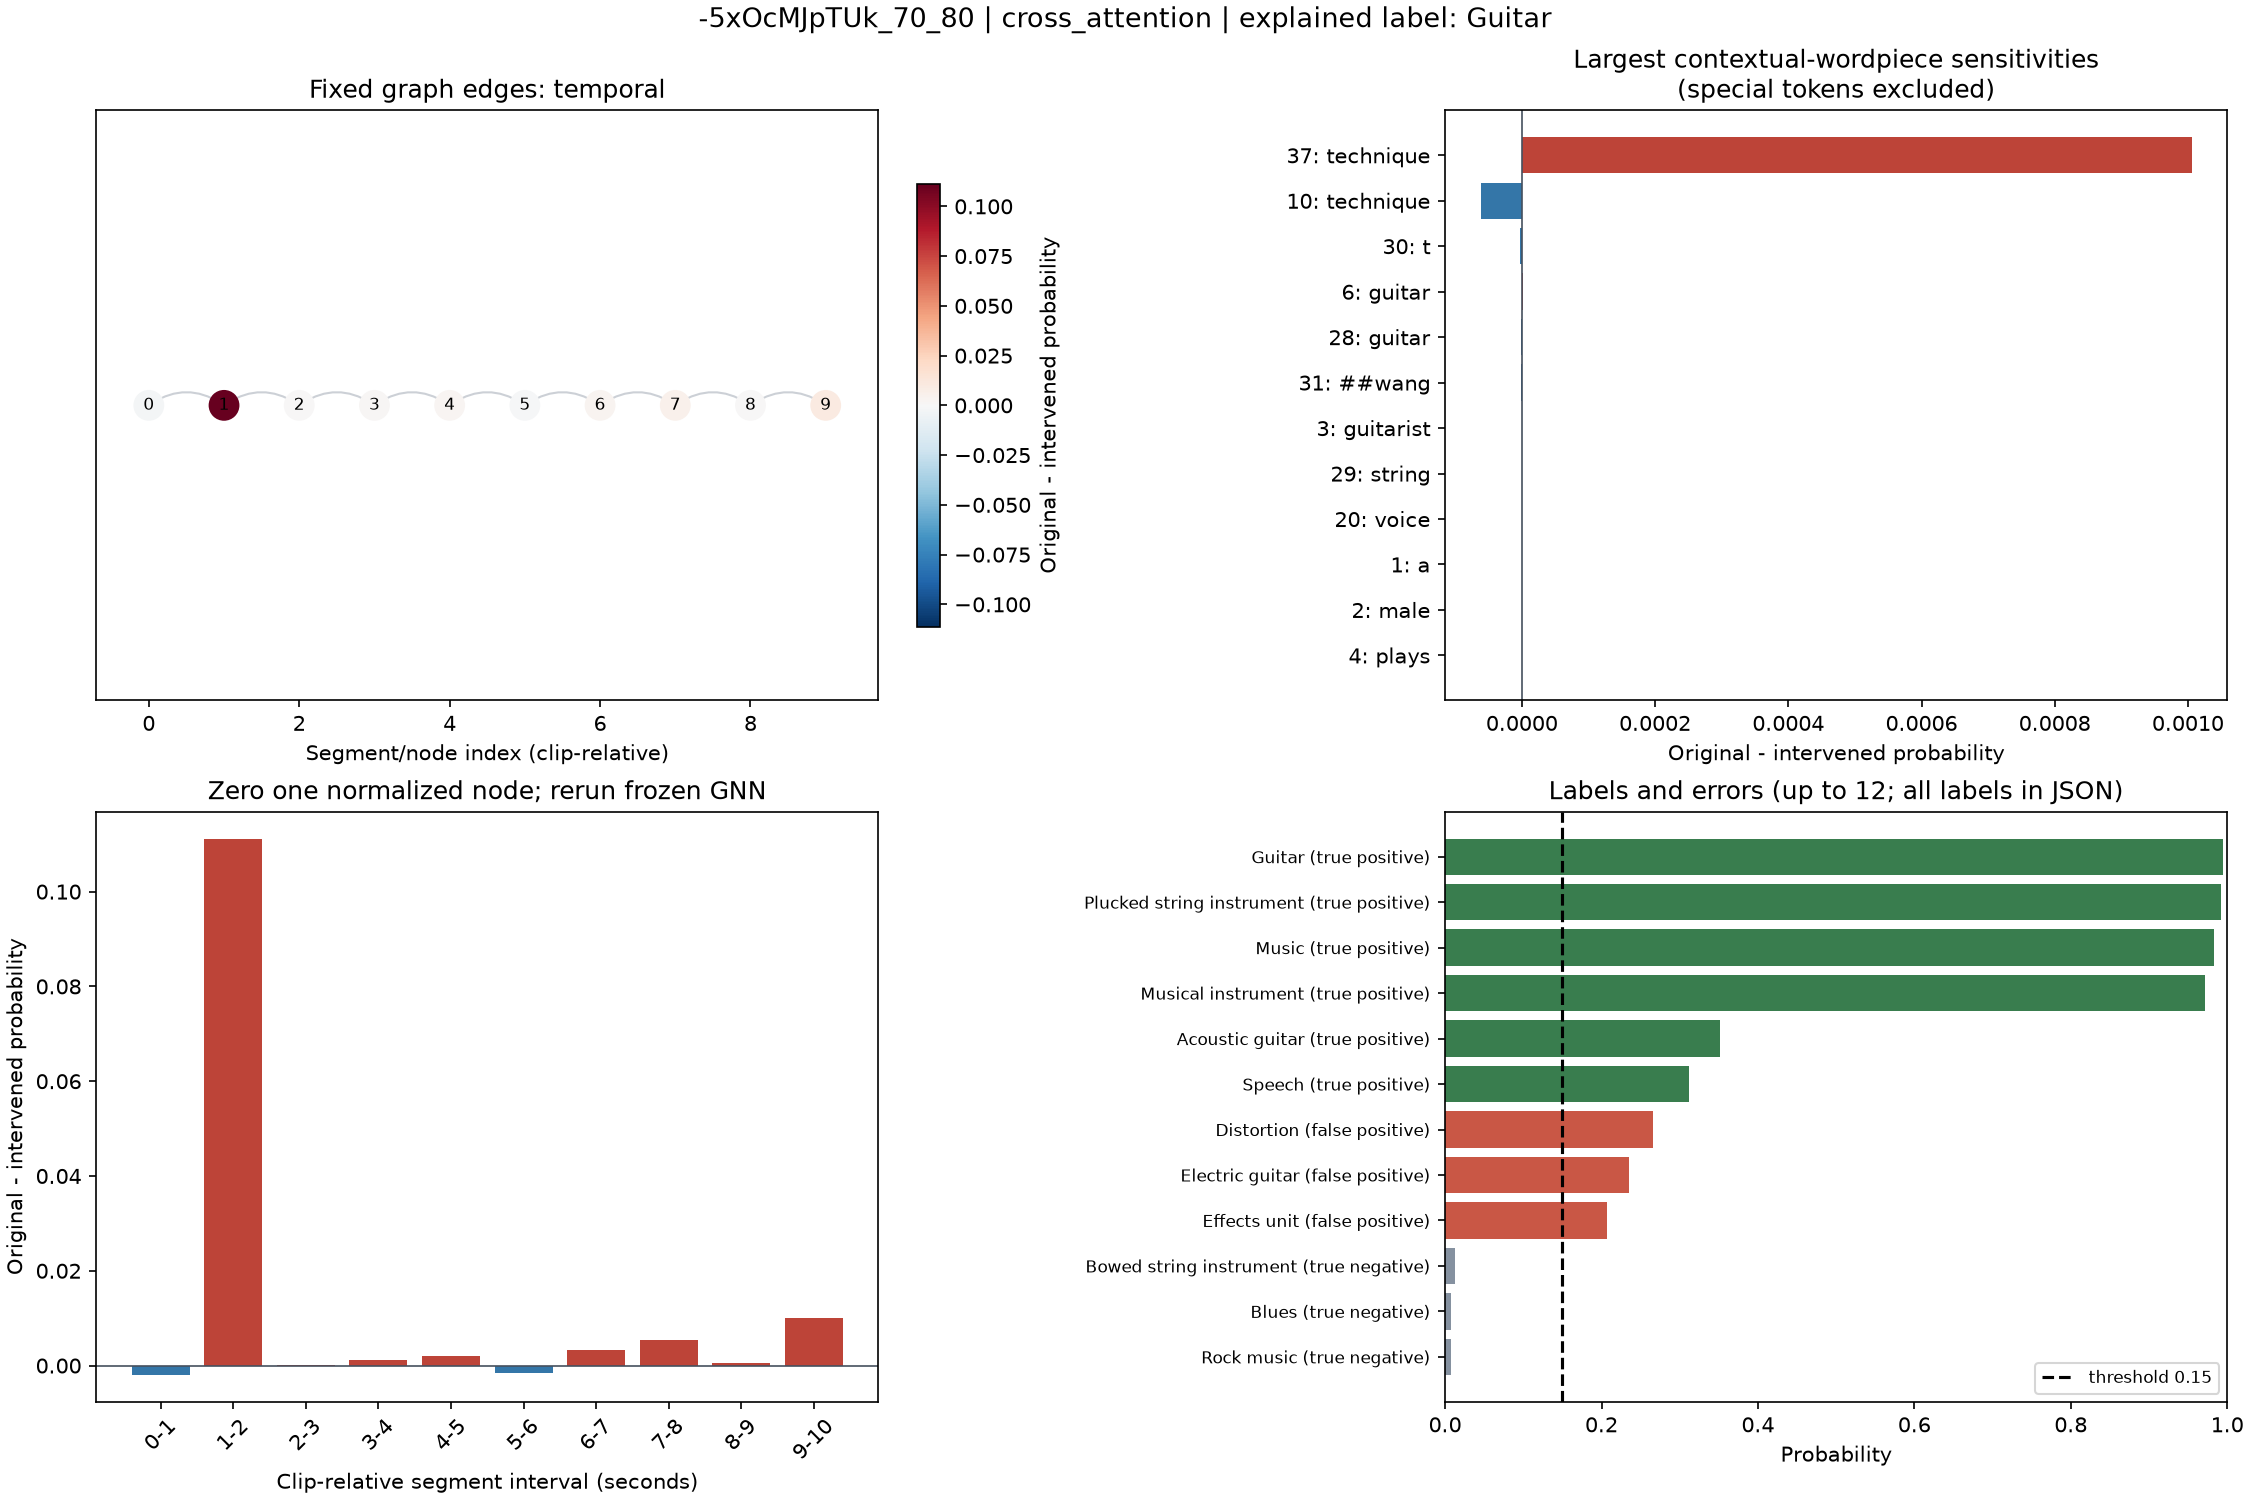

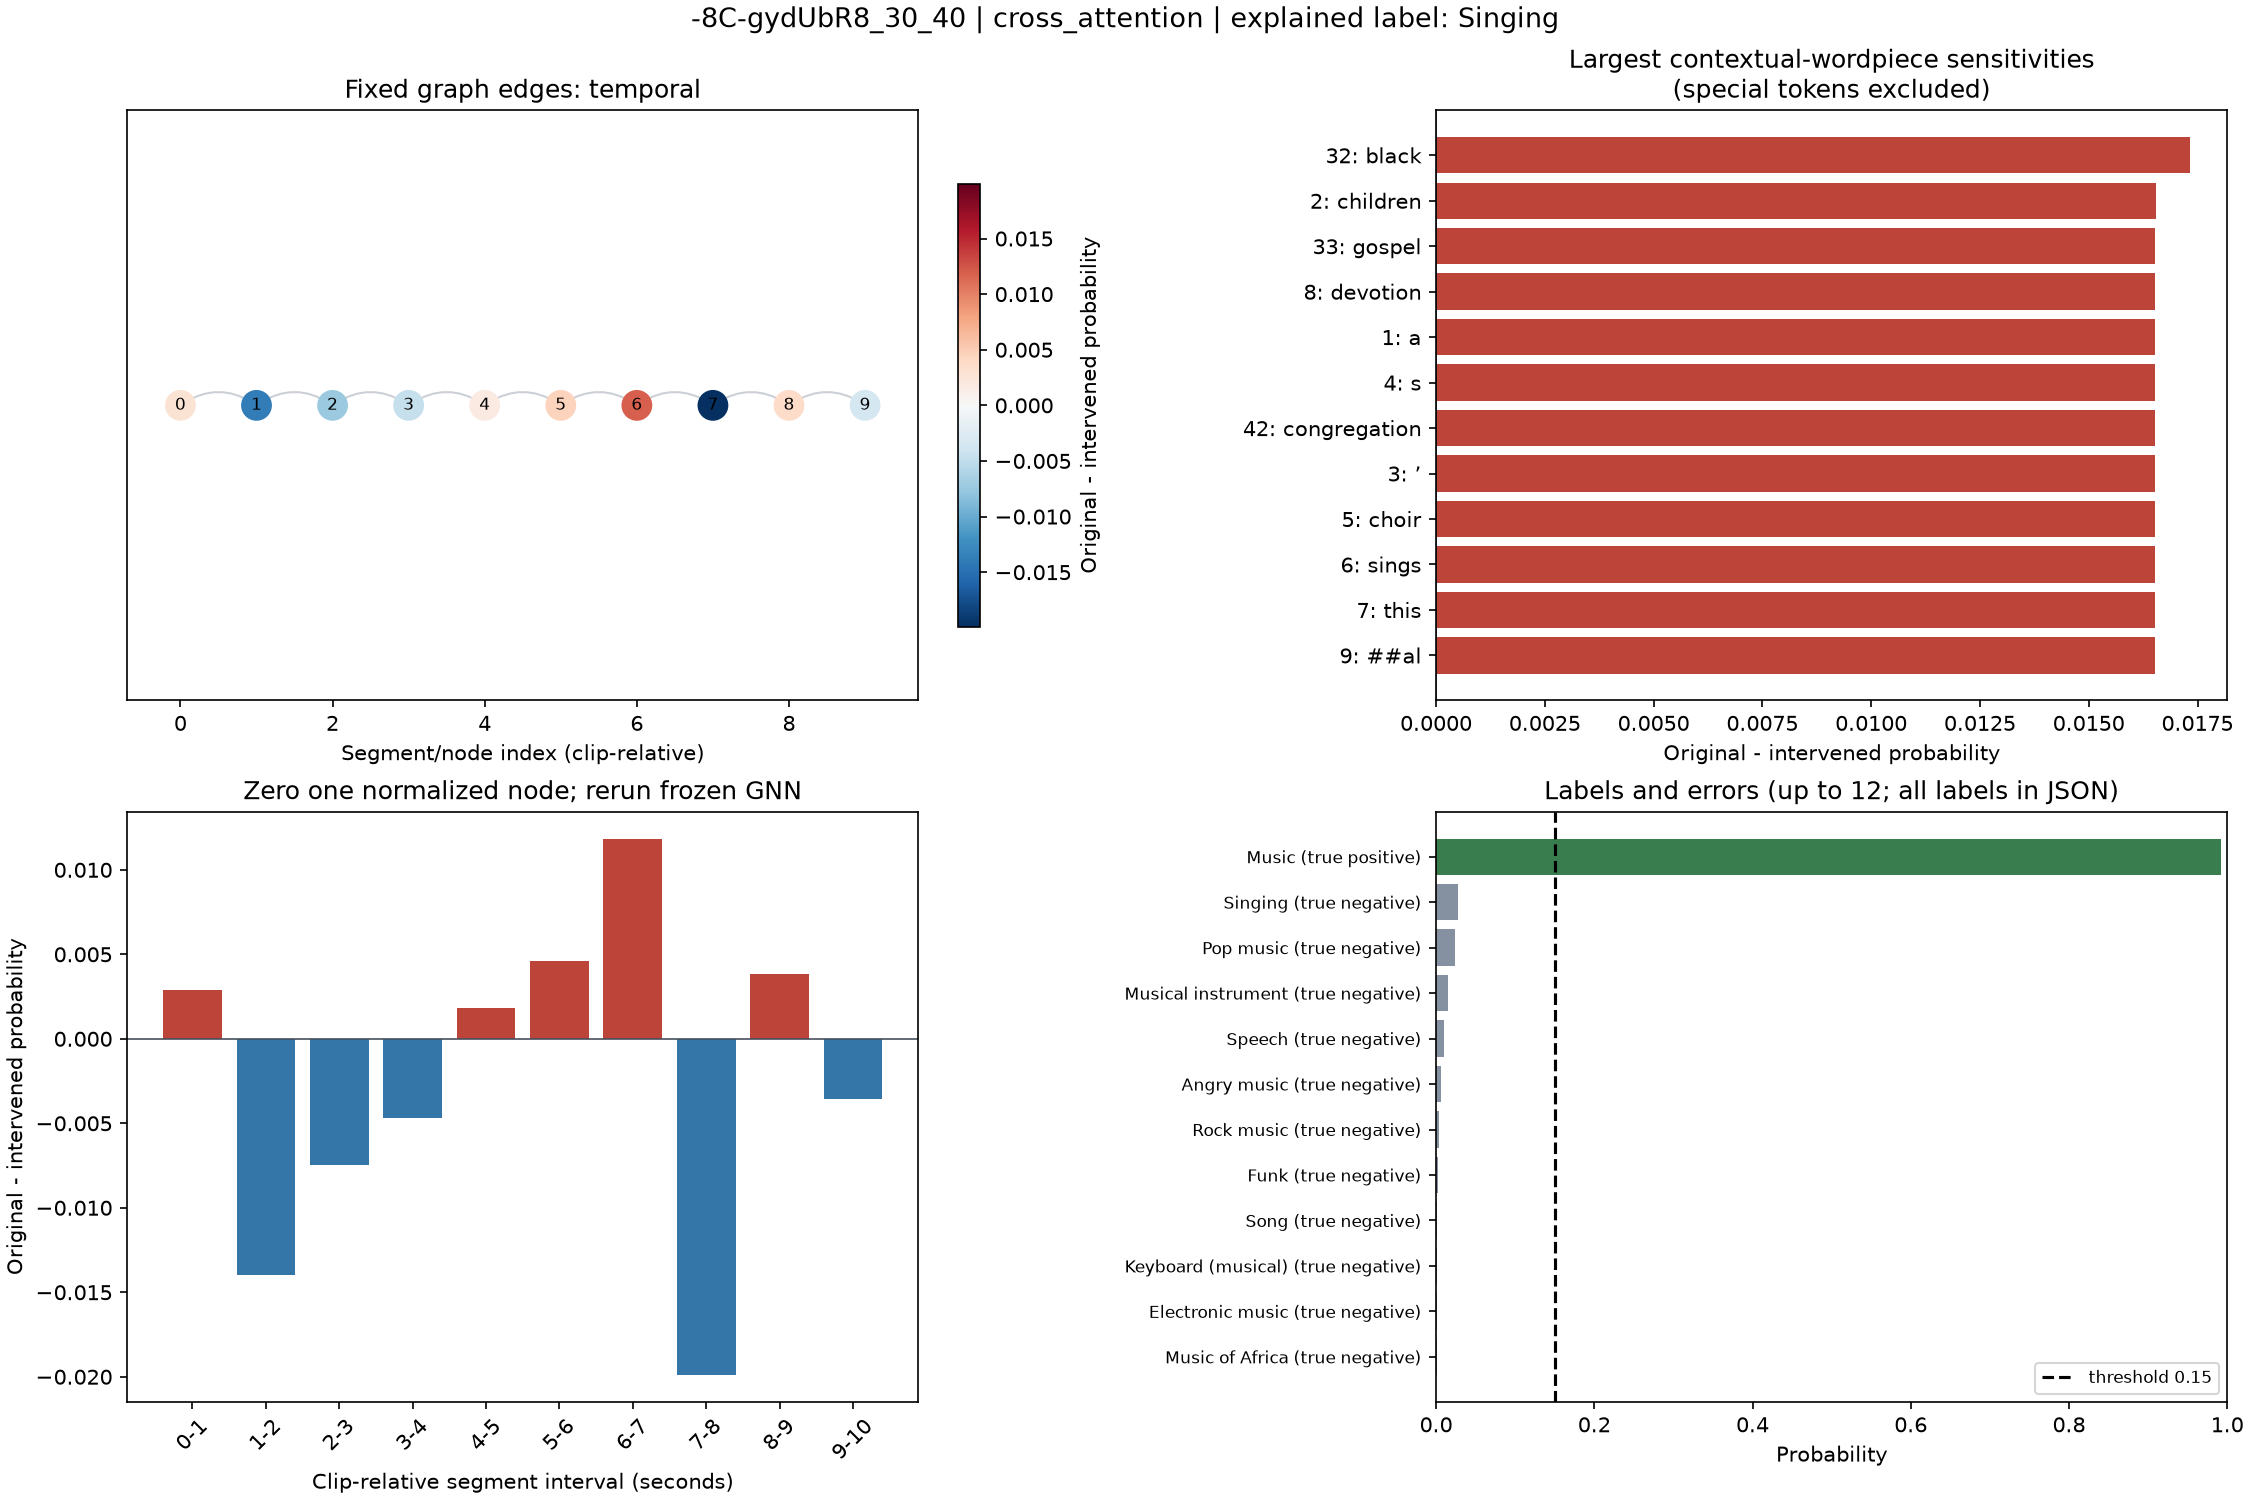

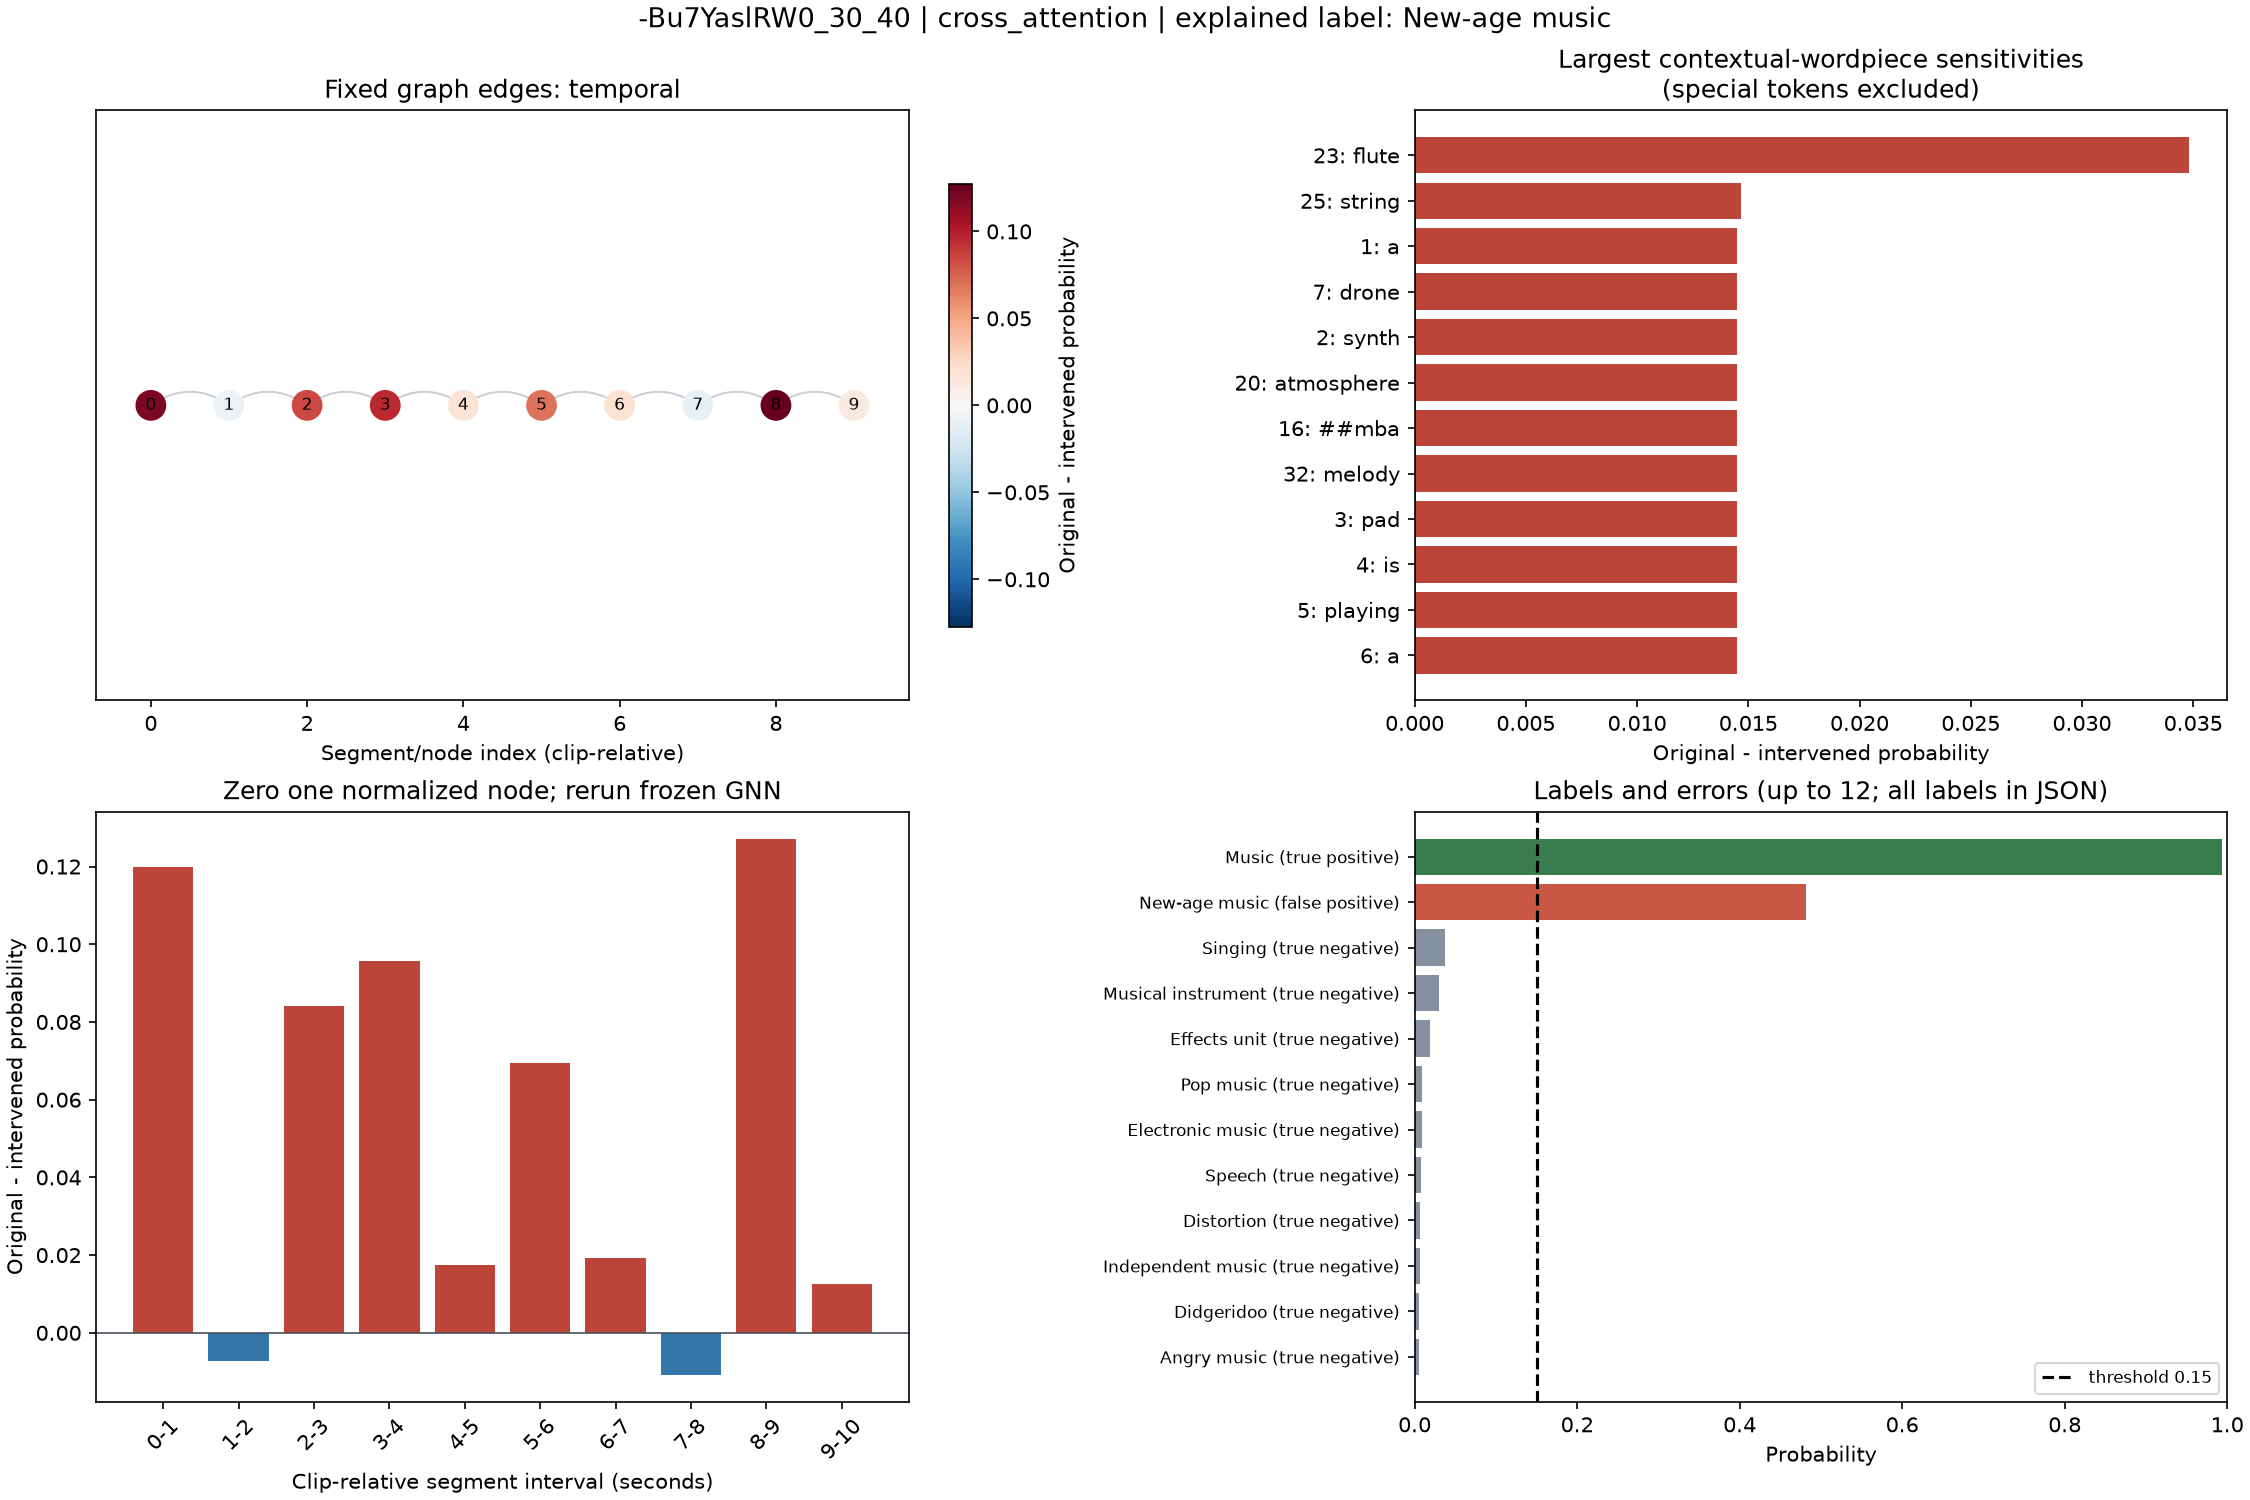

In [4]:
case_root = RUN / 'case_studies'
for path in sorted(case_root.glob('*.md')):
    display(Markdown(re.sub(r'!\[[^\]]*\]\([^)]*\)', '', path.read_text(encoding='utf-8'))))
for path in sorted(case_root.glob('*.png')):
    display(Image(filename=str(path)))

## Interpretation and limitations

Read the measured report for fusion gains or negative findings, failure patterns
and exact timings. Independent targets remove mechanical caption-derived label
leakage, but captions naturally mention labeled instruments and sound types.
Missing-audio selection bias, incomplete annotations, modest graph features and
reused encoders limit generalization. Attention and t-SNE are descriptive.

In [5]:
report_text = (ROOT / 'report/task3_results.md').read_text(encoding='utf-8')
display(Markdown(re.sub(r'!\[[^\]]*\]\([^)]*\)', '', report_text)))

# Task 3 — measured frozen GNN–BERT fusion

**Task 3 is complete on the available 3,964-clip MusicCaps cohort:** five heads,
three seeds, 15 trained and evaluated checkpoints, verified predictions, training/validation curves,
embedding plots, three case studies and failure analysis. The run is
`results/task3/available_run1/`, rebuilt and verified on 2026-09-10.
Missing Task 3 modules were recovered from the supplied source/test archives;
the real feature cache and experiment outputs were regenerated locally. The
measurements below describe this verified run and supersede the earlier draft.

**Fusion did not improve over the text control on the selection metric.**
BERT-only wins mean validation Macro-F1 (0.4621). Gated fusion is the best fusion
mode on validation (0.4353), and its held-out Macro-F1 is 0.3705 versus 0.3850 for
BERT-only. This negative finding is part of the completed experiment.

## Frozen comparison

Values are mean ± sample standard deviation over head seeds 42, 43 and 44.
Every test run uses the same 606 clips. Standard deviations describe head
initialization/batch-order variation, not encoder variability, confidence
intervals or statistical significance.

| Head | Validation Macro-F1 | Test Macro-F1 | Test Micro-F1 | Test mAP |
|---|---:|---:|---:|---:|
| BERT-only | 0.4621 ± 0.0040 | 0.3850 ± 0.0058 | 0.6564 ± 0.0105 | 0.3892 ± 0.0058 |
| GNN-only | 0.2967 ± 0.0050 | 0.2539 ± 0.0119 | 0.5632 ± 0.0352 | 0.2680 ± 0.0036 |
| Concatenation | 0.4228 ± 0.0070 | 0.3839 ± 0.0124 | 0.6560 ± 0.0034 | 0.3994 ± 0.0038 |
| Gated fusion | 0.4353 ± 0.0048 | 0.3705 ± 0.0013 | 0.6466 ± 0.0149 | 0.3995 ± 0.0110 |
| Cross-attention | 0.4232 ± 0.0058 | 0.3665 ± 0.0102 | 0.6453 ± 0.0061 | 0.3861 ± 0.0048 |



Gated fusion improves test Macro-F1 by 0.1166 over the graph control but loses
0.0145 against BERT-only. Its mAP is 0.0103 higher than BERT-only, while its
thresholded F1 scores are lower. This describes a difference between ranking and
classification performance; it does not justify switching the validation-selected
winner. Concatenation nearly matches BERT-only test F1, but it also loses on
validation. No configuration was changed after viewing test results.

## Data and encoder reuse

The frozen cohort contains **2,775 train / 583 validation / 606 test** examples.
All heads share 30 independent `MusicCaps.audioset_positive_labels` targets,
vocabulary order, video-ID splits, captions and graphs. The vocabulary was fitted
on Task 1 training data. Missing audio was filtered without resplitting or
reselecting labels. These are available-audio subset results, not full-MusicCaps
or artist-disjoint results.

The text encoder is Task 1's two-epoch fine-tuned `distilbert-base-uncased`,
frozen during Task 3. Its 3,864 original training captions include the 2,775
paired training examples and 1,089 additional training-only examples without
usable paired audio. All paired held-out IDs/captions preserve their original
held-out partitions. The graph encoder is Task 2's seed-42 temporal GraphSAGE,
chosen from the architecture selected by mean validation Macro-F1; it trained on
the 2,775 paired training clips. Both encoders are identical across all 15 runs.
These controls are newly trained heads, not historical Task 1/2 scores.
The paired Task 3 inputs are identical across heads; historical encoder training
cohorts are not identical. Results therefore compare heads over reused encoders,
not encoders trained with equal numbers of examples.

Preparation verifies training CSV hashes and saved split metadata, IDs, captions,
label vectors/order, the graph cached-dataset fingerprint and training
normalization. It permits the relocated Task 2 path only after exact fingerprint
agreement. A disk-backed extraction buffer and mapped cache avoid duplicating
the 1.56 GB token tensor in RAM. The cache has tokens `[3964,128,768]`, masks
`[3964,128]`, graph embeddings `[3964,256]` and targets `[3964,30]`.
See [compact feature provenance](../results/task3/feature_summary.json).

## Heads and training

The BERT head projects the contextual CLS vector. The GNN head projects the
concatenated mean/max graph readout. Concatenation joins both width-64 projections;
gated fusion learns a per-dimension sigmoid mixture. Single-query cross-attention
uses the graph projection as query, masked contextual BERT tokens as keys/values,
and a graph residual. Every head ends with dropout 0.1 and a linear 30-label layer.

Settings fixed before testing: at most 20 epochs, batch size 16, hidden width 64,
AdamW learning rate 0.001 and default weight decay 0.01, BCEWithLogitsLoss,
gradient-norm clipping at 1.0, patience 5 and CPU with six PyTorch threads.
Every epoch selects a global threshold using validation Macro-F1 over
0.05–0.95 in steps of 0.05; lower thresholds break ties. Best validation epochs
and their thresholds are saved. The suite then selects the mode using mean
validation Macro-F1 across seeds and freezes checkpoint hashes before testing.

| Head | Trainable head parameters | Mean head-training seconds |
|---|---:|---:|
| BERT-only | 51,166 | 4.03 |
| GNN-only | 18,398 | 3.01 |
| Concatenation | 69,534 | 3.50 |
| Gated fusion | 75,870 | 3.32 |
| Cross-attention | 84,254 | 20.56 |

Counts exclude frozen encoders. Times include epoch validation/checkpoint saves
but exclude encoder extraction and final testing. The suite timer was 122.93
seconds including per-seed outputs. These are local elapsed measurements, not
isolated hardware benchmarks. The architectures have different parameter counts.

Macro-F1 averages all 30 label F1 scores; Micro-F1 pools decisions. mAP averages
per-label average precision over labels with test-positive support, rather than
trapezoidal precision–recall area. All 30 labels have test positives in this run.
Absent positive annotations are treated as zero operationally.

## Failures and three fixed cases

The selected gated model has weak test AP for Pop music (0.0316; 7 positives),
Funk (0.1514; 11) and Song (0.1692; 13). It has higher AP for Music (0.9394; 497),
Didgeridoo (0.9040; 9) and Wind instrument (0.8688; 30). Small support makes some
rankings unstable. See [per-label evidence](../results/task3/available_run1/analysis/per_label.csv).

Across the three paired seeds, gated fusion improves per-example F1 over BERT
in 438 seed/example pairs, worsens it in 452 and ties in 928. These 1,818 pairs
reuse the same 606 clips, so they are not independent observations. They show
mixed local changes rather than a consistent gain.

The first three validation IDs, fixed before looking at outcomes, are traced
through the seed-42 cross-attention head regardless of the winning architecture:

1. **Guitar tutorial, `-5xOcMJpTUk_70_80`:** 6 true positives, 3 false positives and 0 false negatives at threshold 0.15.
   False-positive labels: Effects unit, Electric guitar, Distortion. False-negative labels: none.
   The focal Guitar score is 0.9940 (target 1).
   Zeroing the 1–2 second normalized node changes this score by +0.1112 (original minus intervened).
   The largest lexical-vector effect is `technique` at +0.0010.

2. **Choir recording, `-8C-gydUbR8_30_40`:** 1 true positive, 0 false positives and 0 false negatives at threshold 0.15.
   False-positive labels: none. False-negative labels: none.
   The focal Singing score is 0.0277 (target 0).
   Zeroing the 7–8 second normalized node changes this score by -0.0199 (original minus intervened).
   The largest lexical-vector effect is `black` at +0.0173.

3. **Ambient synth clip, `-Bu7YaslRW0_30_40`:** 1 true positive, 1 false positive and 0 false negatives at threshold 0.15.
   False-positive labels: New-age music. False-negative labels: none.
   The focal New-age music score is 0.4821 (target 0).
   Zeroing the 8–9 second normalized node changes this score by +0.1272 (original minus intervened).
   The largest lexical-vector effect is `flute` at +0.0348.

[Full case traces and figures](../results/task3/available_run1/case_studies/cases.md)
retain all targets, probabilities and token/segment effects. Interventions zero
one cached contextual vector or one standardized node-feature vector. They retain
other token information and graph edges. Such out-of-distribution interventions
measure representation sensitivity, not causal importance of words or sounds.
t-SNE plots are also descriptive. The choir case has only Music annotated
within the selected vocabulary, while the ambient case has an unannotated
New-age prediction. Incomplete labels can contribute to apparent errors;
these cases were not independently relabeled.

The [selected gated-fusion embedding plot](../results/task3/available_run1/analysis/fusion_embeddings.png)
uses saved seed-42 validation representations; coordinates and sample IDs are
preserved alongside it. Per-seed overall-winner plots remain in each seed folder.

The weak graph control and stronger text control are consistent with audio adding
limited useful information under this setup. Coarse one-second segment features,
global graph pooling, fixed encoders and label imbalance are plausible constraints;
this experiment does not isolate which causes the negative fusion result. More
parameters and cross-attention did not yield a validation gain over BERT-only.

## Verification and reproducibility

- [Completion audit](task3_completion_audit.md) maps every Task 3 requirement
  to verified evidence and records the frozen-encoder scope qualifications.
- All **73 repository tests passed**, including 19 Task 3 tests for shapes,
  masks, gradients, feature extraction, provenance, restoration and suite audits.
- [Verification](../results/task3/available_run1/verification.json) recomputes all
  15 validation/test metric sets and validation thresholds, checks aligned
  IDs/targets, hashes and frozen selection, and verifies published CSV means/std.
- [Full comparison](../results/task3/available_run1/comparison.csv),
  [aggregates](../results/task3/available_run1/comparison_aggregate.csv),
  [failure analysis](../results/task3/available_run1/analysis/README.md),
  checkpoints, prediction archives and epoch curves are preserved locally.
- [Test verification](../results/task3/test_verification.json) records 73 passing tests and exit code 0.
- The [review notebook](../notebooks/task3_fusion.ipynb) reads measured results
  by default and runs saved-checkpoint inference on three real validation pairs;
  its synthetic training demonstration is opt-in.
- [Run guide](../docs/task3/README.md) gives exact preparation, training,
  evaluation, analysis and case-generation commands. Raw audio and large caches
  remain excluded from Git; preserve them locally for full reproduction.

The independent targets remove mechanical caption-derived target leakage, but
captions naturally mention labeled instruments and music types. Available-audio
selection bias, incomplete annotations, limited label support and reused encoders
remain limitations. No statistical significance, listener assessment or
cross-dataset generalization is claimed.


## Fusion inference from a saved checkpoint

Restore the validation-selected fusion head for the predeclared first seed and
run the first three validation clips through it. These inputs are the aligned,
frozen DistilBERT tokens and GraphSAGE representations, prepared from real audio
and captions. This demonstrates cached-pair inference; raw new audio/captions
must first use the same tokenizer, graph preprocessing and frozen encoders.
The saved threshold and label order are used unchanged.

In [6]:
import torch
from src.task3.data import load_features, feature_fingerprint
from src.task3.models import FusionClassifier
from src.task3.evaluate import predict_features
torch.set_num_threads(6)
entry = next(r for r in selection['runs']
             if r['mode'] == selection['selected_fusion'] and r['seed'] == selection['seeds'][0])
checkpoint_path = RUN / entry['checkpoint']
assert feature_fingerprint(checkpoint_path) == entry['checkpoint_sha256']
saved = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
features_path = Path(experiment['features'])
if not features_path.exists():
    features_path = ROOT / 'data/processed/task3_available/features.pt'
assert feature_fingerprint(features_path) == saved['feature_sha256']
data = load_features(features_path, mmap=True)
assert data['label_names'] == saved['label_names']
model = FusionClassifier(**saved['dimensions'], mode=saved['mode']).eval()
model.load_state_dict(saved['state_dict'])
indices = [i for i, split in enumerate(data['splits']) if split == 'validation'][:3]
probabilities, embeddings = predict_features(model, data, indices, batch_size=3, device='cpu')
names = json.loads((ROOT / 'src/task1/audioset_names.json').read_text(encoding='utf-8'))
rows = []
for i, scores in zip(indices, probabilities):
    rows.append({'sample_id': data['sample_ids'][i], 'caption': data['texts'][i],
                 'true_labels': [names.get(tag, tag) for tag, y in zip(saved['label_names'], data['labels'][i]) if y],
                 'predictions': {names.get(tag, tag): round(float(score), 4)
                                 for tag, score in zip(saved['label_names'], scores) if score >= saved['threshold']}})
print('Head:', saved['mode'], '| Threshold:', saved['threshold'], '| Embeddings:', embeddings.shape)
display(pd.DataFrame(rows))
del data

C:\Users\Roman\OneDrive\Documents\Neural_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Head: gated | Threshold: 0.15 | Embeddings: (3, 64)


,sample_id,caption,true_labels,predictions
0,-5xOcMJpTUk_70_80,A male guitarist plays the guitar and speaks a...,"[Music, Musical instrument, Guitar, Plucked st...","{'Music': 0.993, 'Musical instrument': 0.9535,..."
1,-8C-gydUbR8_30_40,A children’s choir sings this devotional melod...,[Music],{'Music': 0.9941}
2,-Bu7YaslRW0_30_40,A synth pad is playing a drone sound in the lo...,[Music],"{'Music': 0.9971, 'New-age music': 0.192}"


## Optional offline demonstration

Set `RUN_SYNTHETIC_DEMO` to `True` to exercise training in a fresh temporary
directory. Random synthetic features are pipeline diagnostics, never real-data
results. Full reproduction commands live in `docs/task3/README.md`.

In [7]:
RUN_SYNTHETIC_DEMO = False
if RUN_SYNTHETIC_DEMO:
    from datetime import datetime
    from src.task3.data import make_demo
    from src.task3.train import run_experiments
    output = ROOT / 'tmp' / ('task3_demo_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
    features = make_demo(output.with_suffix('.features.pt'))
    demo = run_experiments(features, output, epochs=2, device='cpu', evaluate_test=False)
    display(pd.read_csv(output / 'comparison.csv'))
    print('Synthetic:', demo['provenance']['synthetic'])